<a href="https://colab.research.google.com/github/AI-Lab-2025-2-3rd/ai-project-codex/blob/main/COdeX_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Model 1: BERT 기반

In [10]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from transformers import BertTokenizer, TFBertForSequenceClassification

# ==============================
# 1️⃣ model.zip 압축 해제
# ==============================
zip_path = "/content/bert_trained_model.zip"   # 업로드된 파일 경로
extract_dir = "/content/model"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

print("✅ model.zip 압축 해제 완료!")

# ==============================
# 2️⃣ 모델과 토크나이저 로드
# ==============================
model_dir = extract_dir
tokenizer = BertTokenizer.from_pretrained(model_dir)
model = TFBertForSequenceClassification.from_pretrained(model_dir)
print("✅ 모델 불러오기 완료!")

# ==============================
# 3️⃣ 테스트 데이터 불러오기 (CSV)
# ==============================
test_df = pd.read_csv("/content/clean_train_without_tag.csv", header=1, names=["id", "text", "label"])

sample_df = (
    test_df.dropna(subset=["text"])  # text가 없는 행 제거
            .sample(n=100, random_state=42)
            .reset_index(drop=True)
)
sample_df["text"] = sample_df["text"].astype(str)

print(f"테스트셋 크기: {len(sample_df)}개")

X_test = sample_df["text"].tolist()
y_test = sample_df["label"].tolist()

✅ model.zip 압축 해제 완료!


Some layers from the model checkpoint at /content/model were not used when initializing TFBertForSequenceClassification: ['dropout_37']
- This IS expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
All the layers of TFBertForSequenceClassification were initialized from the model checkpoint at /content/model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertForSequenceClassification for predictions without further training.


✅ 모델 불러오기 완료!
테스트셋 크기: 100개


In [11]:
# ==============================
# 4️⃣ 입력 토큰화
# ==============================
encodings = tokenizer(X_test, truncation=True, padding=True, return_tensors="tf")

In [12]:
# ==============================
# 5️⃣ 예측 수행
# ==============================
preds = model.predict(dict(encodings)).logits
y_pred = np.argmax(preds, axis=1)

4/4 [==============================] - 46s 8s/step


In [13]:
# ==============================
# 6️⃣ 성능 지표 계산
# ==============================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n📊 Test Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}\n")

print(classification_report(y_test, y_pred))


📊 Test Results
Accuracy : 0.9400
Precision: 0.9387
Recall   : 0.9400
F1 Score : 0.9374

              precision    recall  f1-score   support

           0       0.90      0.69      0.78        13
           1       0.92      0.96      0.94        23
           2       0.95      0.98      0.97        64

    accuracy                           0.94       100
   macro avg       0.92      0.88      0.90       100
weighted avg       0.94      0.94      0.94       100



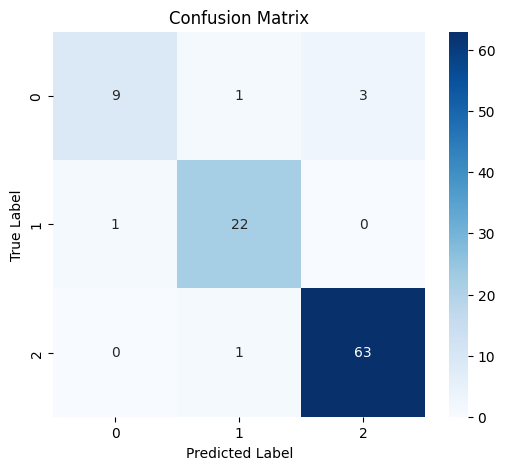

In [14]:
# ==============================
# 7️⃣ 혼동 행렬 시각화
# ==============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

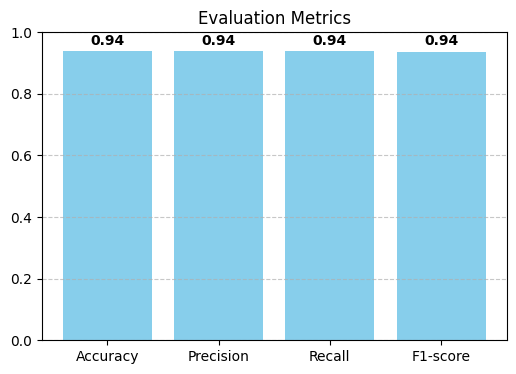

In [15]:
# ==============================
# 8️⃣ 주요 지표 시각화
# ==============================
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}
plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color='skyblue')
plt.title("Evaluation Metrics")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()

# Model 2: RoBERTa 기반

In [18]:
import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)
from transformers import RobertaTokenizer, TFRobertaForSequenceClassification

# ==============================
# 1️⃣ model.zip 압축 해제
# ==============================
zip_path = "/content/roberta_trained_model.zip"   # 업로드된 파일 경로
extract_dir = "/content/model2"

if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

print("✅ model.zip 압축 해제 완료!")

# ==============================
# 2️⃣ 모델과 토크나이저 로드
# ==============================
model_dir = extract_dir
tokenizer = RobertaTokenizer.from_pretrained(model_dir)
model = TFRobertaForSequenceClassification.from_pretrained(model_dir)
print("✅ 모델 불러오기 완료!")

# ==============================
# 3️⃣ 테스트 데이터 불러오기 (CSV)
# ==============================
test_df = pd.read_csv("/content/clean_train_without_tag.csv", header=1, names=["id", "text", "label"])

sample_df = (
    test_df.dropna(subset=["text"])  # text가 없는 행 제거
            .sample(n=100, random_state=42)
            .reset_index(drop=True)
)
sample_df["text"] = sample_df["text"].astype(str)

print(f"테스트셋 크기: {len(sample_df)}개")

X_test = sample_df["text"].tolist()
y_test = sample_df["label"].tolist()

✅ model.zip 압축 해제 완료!


All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at /content/model2.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.


✅ 모델 불러오기 완료!
테스트셋 크기: 100개


In [19]:
# ==============================
# 4️⃣ 입력 토큰화
# ==============================
encodings = tokenizer(X_test, truncation=True, padding=True, return_tensors="tf")

In [20]:
# ==============================
# 5️⃣ 예측 수행
# ==============================
preds = model.predict(dict(encodings)).logits
y_pred = np.argmax(preds, axis=1)

4/4 [==============================] - 47s 10s/step


In [21]:
# ==============================
# 6️⃣ 성능 지표 계산
# ==============================
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted')
rec = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("\n📊 Test Results")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1 Score : {f1:.4f}\n")

print(classification_report(y_test, y_pred))


📊 Test Results
Accuracy : 0.8500
Precision: 0.8621
Recall   : 0.8500
F1 Score : 0.8545

              precision    recall  f1-score   support

           0       0.56      0.69      0.62        13
           1       0.83      0.87      0.85        23
           2       0.93      0.88      0.90        64

    accuracy                           0.85       100
   macro avg       0.78      0.81      0.79       100
weighted avg       0.86      0.85      0.85       100



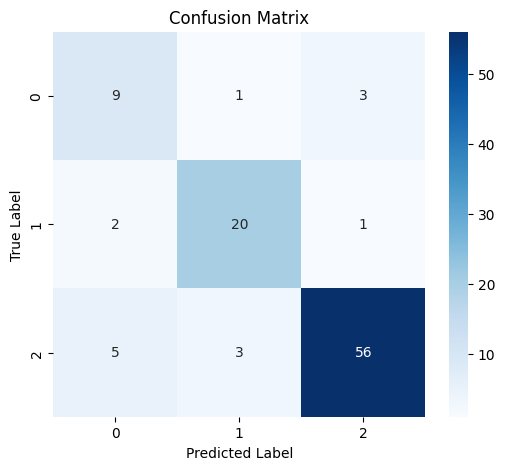

In [22]:
# ==============================
# 7️⃣ 혼동 행렬 시각화
# ==============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

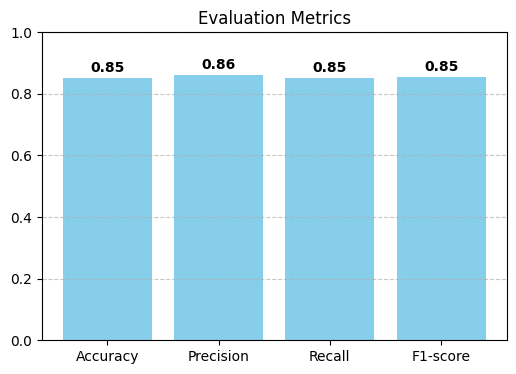

In [23]:
# ==============================
# 8️⃣ 주요 지표 시각화
# ==============================
metrics = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-score': f1}
plt.figure(figsize=(6, 4))
plt.bar(metrics.keys(), metrics.values(), color='skyblue')
plt.title("Evaluation Metrics")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(metrics.values()):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontweight='bold')
plt.show()